# Exploracion de pedidos -- Marketing ROI Pipeline

**Pregunta de negocio:** ¿cómo se comporta el volumen de pedidos, el ticket promedio (AOV) y los tiempos de entrega del e-commerce?

**Fuente de datos:** snapshot local (`../data/raw/*.parquet`) exportado desde `marketing_roi.marts` en MotherDuck vía `export_data.py`. El mart `fct_orders` reconcilia pagos legacy (Postgres) con Stripe (post-migración) -- ver comentarios en `dbt/models/marts/fct_orders.sql`.

**Nota sobre el rango de fechas:** el dataset combina el histórico real Olist (2016-2018) con pedidos sintéticos generados para simular operación "actual". Hay un salto de fechas entre ambos períodos -- es una decisión de diseño documentada en el pipeline, no un bug de sync. Este notebook lo trata como dos eras separadas en vez de promediarlas juntas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("../data/raw")
orders = pd.read_parquet(DATA_DIR / "fct_orders.parquet")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders.shape

(99491, 15)

In [2]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,item_count,items_price,freight_value,order_value,payment_value,payment_source
0,00063b381e2406b52ad429470734ebd5,6a899e55865de6549a58d2c6845e5604,delivered,2018-07-27 17:21:27,2018-07-27 18:00:06,2018-07-30 14:52:00,2018-08-07 13:56:52,2018-08-07,True,1.0,45.00,12.98,57.98,57.98,legacy
1,00337fe25a3780b3424d9ad7c5a4b35e,4b1b5c848616a4b5fa9d76cb1d12067b,delivered,2017-09-25 17:39:29,2017-09-25 17:50:16,2017-09-26 22:31:51,2017-09-27 16:52:40,2017-10-10,True,2.0,119.80,19.88,139.68,139.68,legacy
2,0044c6f6d22dd280534344177c81b989,24436139c80a4ae51c0e3a98469ed7d4,delivered,2018-05-18 16:59:09,2018-05-18 17:15:37,2018-05-21 14:46:00,2018-06-04 20:12:57,2018-06-12,True,1.0,179.93,16.14,196.07,196.07,legacy
3,0098dbda25722a3f019fe252a0cd10b3,6ecb390e8056057a25a1b49c37206958,delivered,2017-09-19 18:05:34,2017-09-21 02:45:37,2017-09-22 14:18:53,2017-10-02 18:06:44,2017-10-11,True,1.0,143.54,21.49,165.03,165.03,legacy
4,00ab1aba567dfebdc39caa4e7ca2f1b2,f2a48c51664d5ca2d7401f95994bb8a9,delivered,2017-09-01 14:01:04,2017-09-01 14:15:16,2017-09-05 21:11:01,2017-09-12 14:07:44,2017-10-03,True,1.0,35.90,12.48,48.38,48.38,legacy


In [3]:
print("Rango de fechas:", orders["order_purchase_timestamp"].min(), "->", orders["order_purchase_timestamp"].max())
print("\nNulos por columna:")
orders.isna().mean().sort_values(ascending=False).round(3)

Rango de fechas: 2016-09-04 21:15:19 -> 2026-08-21 15:16:01.108686

Nulos por columna:


order_delivered_customer_date    0.030
order_delivered_carrier_date     0.018
item_count                       0.008
items_price                      0.008
freight_value                    0.008
order_approved_at                0.002
payment_value                    0.000
payment_source                   0.000
order_id                         0.000
customer_id                      0.000
order_status                     0.000
order_purchase_timestamp         0.000
order_estimated_delivery_date    0.000
is_delivered                     0.000
order_value                      0.000
dtype: float64

## Volumen de pedidos por mes

Separamos la era histórica Olist (hasta 2018) de la era "actual" sintética para no promediar dos regímenes distintos en el mismo eje.

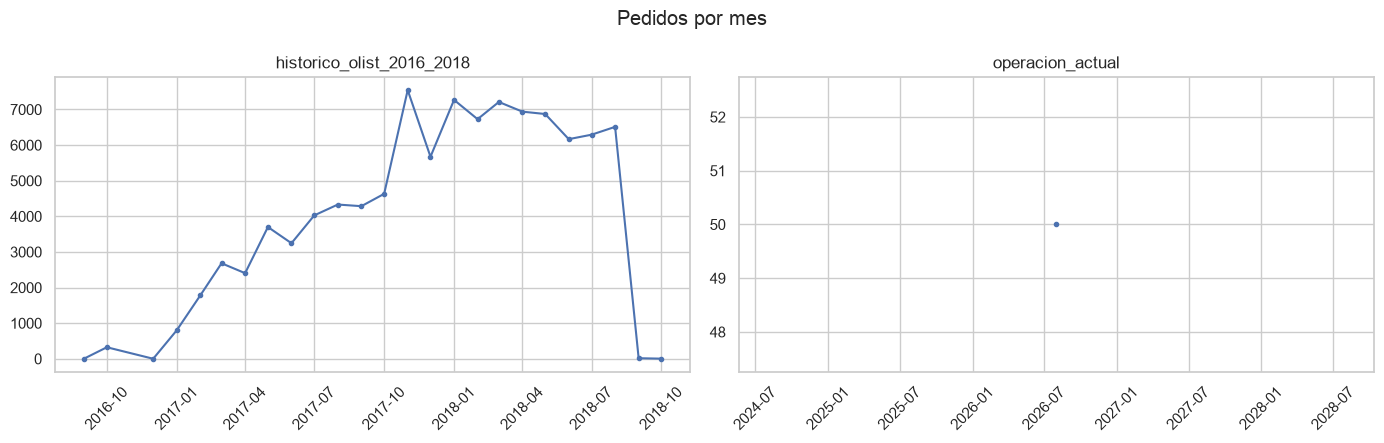

In [4]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
orders["era"] = orders["order_purchase_timestamp"].apply(
    lambda d: "historico_olist_2016_2018" if d.year <= 2018 else "operacion_actual"
)
monthly = orders.groupby(["era", "month"]).size().rename("n_orders").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, era in zip(axes, monthly["era"].unique()):
    sub = monthly[monthly["era"] == era]
    ax.plot(sub["month"], sub["n_orders"], marker="o", markersize=3)
    ax.set_title(era)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Pedidos por mes")
fig.tight_layout()

## Estados del pedido

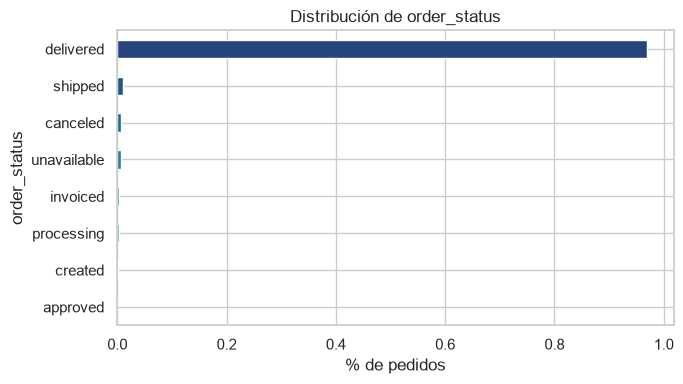

In [5]:
status_counts = orders["order_status"].value_counts(normalize=True).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
status_counts.plot(kind="barh", ax=ax, color=sns.color_palette("crest", len(status_counts)))
ax.set_xlabel("% de pedidos")
ax.set_title("Distribución de order_status")
fig.tight_layout()

## Ticket promedio (AOV)

`order_value` = `items_price + freight_value` (definido en el mart). `payment_value` es lo efectivamente cobrado (legacy o Stripe, nunca ambos sumados).

count    99491.00
mean       159.41
std        220.08
min          0.00
25%         61.05
50%        104.59
75%        176.16
max      13664.08
Name: order_value, dtype: float64


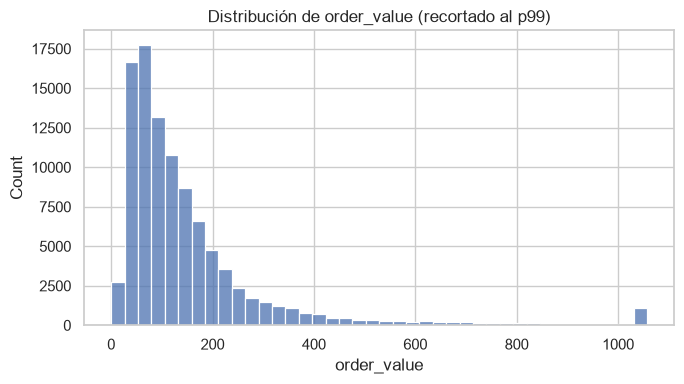

In [6]:
print(orders["order_value"].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(orders["order_value"].clip(upper=orders["order_value"].quantile(0.99)), bins=40, ax=ax)
ax.set_title("Distribución de order_value (recortado al p99)")
fig.tight_layout()

In [7]:
aov_by_source = orders.groupby("payment_source")["payment_value"].agg(["mean", "median", "count"]).round(2)
print(aov_by_source)

print("\nControlando por era (payment_source x era) -- ojo, Stripe solo existe en la era reciente:")
aov_by_source_era = (
    orders.groupby(["era", "payment_source"])["payment_value"]
    .agg(["mean", "median", "count"])
    .round(2)
)
aov_by_source_era


                  mean  median  count
payment_source                       
legacy          161.04  105.30  99470
stripe          317.03  245.24     20

Controlando por era (payment_source x era) -- ojo, Stripe solo existe en la era reciente:


mean  median  count
era                       payment_source                       
historico_olist_2016_2018 legacy          160.99  105.29  99440
operacion_actual          legacy          334.08  306.66     30
                          stripe          317.03  245.24     20

## Tiempos de entrega

Solo pedidos con `is_delivered = true` y ambas fechas presentes.

count    96495.0
mean        12.7
std         44.8
min          0.0
25%          6.0
50%         10.0
75%         15.0
max       3373.0
Name: delivery_days, dtype: float64


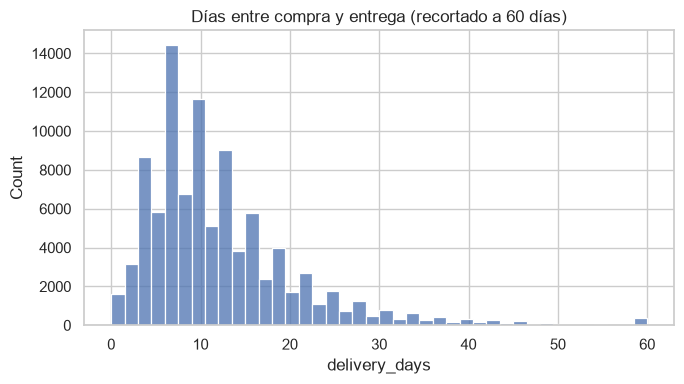

In [8]:
delivered = orders[orders["is_delivered"] == True].copy()
delivered["order_delivered_customer_date"] = pd.to_datetime(delivered["order_delivered_customer_date"])
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days
delivered = delivered[delivered["delivery_days"].notna() & (delivered["delivery_days"] >= 0)]

print(delivered["delivery_days"].describe().round(1))
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(delivered["delivery_days"].clip(upper=60), bins=40, ax=ax)
ax.set_title("Días entre compra y entrega (recortado a 60 días)")
fig.tight_layout()

## Conclusiones

- El volumen de pedidos y su estacionalidad deben leerse **por era** (histórico Olist vs. operación actual sintética) -- combinarlos en un solo eje temporal produce un salto artificial de 7 años.
- `order_status` está dominado por `delivered`; los estados de cancelación/no disponibilidad son marginales, lo que es consistente con un e-commerce maduro.
- El AOV **crudo** por `payment_source` parece muy distinto (legacy \$161 vs. Stripe \$317), pero es un efecto de confusión con la era, no del método de pago: **todos** los pedidos Stripe (n=20) son de la operación actual (2026), mientras que legacy es 99.97% histórico Olist (AOV mucho más bajo). Controlando por era (ver tabla arriba), legacy y Stripe dentro de la operación actual sí son comparables (~\$334 vs. ~\$317, ambos con n pequeño) -- consistente con que `generate_stripe.py` reutiliza el mismo `payment_value` que la fila legacy (no es un segundo cobro independiente). La comparación sin controlar por era es engañosa y no debería usarse para concluir nada sobre el rail de pago.
- La distribución de tiempos de entrega tiene una cola larga; vale la pena cruzarla con `review_score` (ver notebook 03) para ver si la demora explica insatisfacción.